In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import geemap,ee
from shapely.geometry import mapping
import os
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib.pyplot as plt
from libpysal.weights import Queen, KNN
from esda.moran import Moran, Moran_Local
from splot.esda import moran_scatterplot, lisa_cluster
import rasterio
import numpy as np
import glob
import os
from rasterio.features import shapes
import geopandas as gpd
from shapely.geometry import shape
from shapely.geometry import Point
from libpysal.weights import lag_spatial
from esda.moran import Moran_Local
import matplotlib.patches as mpatches
from shapely.geometry import box
from shapely import make_valid
import rasterio.mask
from pyproj import Transformer
from rasterio.warp import calculate_default_transform, reproject, Resampling



In [2]:
ynp_path = os.path.join('YELL_tracts', 'yell_boundary.shp')
ynp = gpd.read_file(ynp_path)

# Agrupar todos los territorios por año.

In [322]:
wolf_path = os.path.join('1995_2022-YELL-wolf-data', '1995_2022-mcps', '1995_2007_mcps')

all_wolf_yearly = {}

for p in os.listdir(wolf_path):
    if 'shp' in p and 'all' in p:
        path = os.path.join(wolf_path, p)
        df = gpd.read_file(path)
        df = df.set_crs("EPSG:26912")
        year = p[:4]
        all_wolf_yearly[year] = df

        print('key added', year)
        print(df.crs)
        

key added 2000
EPSG:26912
key added 2001
EPSG:26912
key added 2002
EPSG:26912
key added 2003
EPSG:26912
key added 2005
EPSG:26912


In [324]:
ter2006 = os.path.join(wolf_path, '2006_ynp_mcp.shp')
df06 = gpd.read_file(ter2006)
all_wolf_yearly['2006'] = df06

In [325]:
ter_2008p_path = os.path.join('1995_2022-YELL-wolf-data', '1995_2022-mcps')
ter_2008_plus = os.listdir(ter_2008p_path)

In [326]:
def all_ters(path):
    n_path = os.path.join(ter_2008p_path, path)
    
    gdf_list = []

    for ter in os.listdir(n_path):
        if 'shp' in ter and 'xml' not in ter:
            p = os.path.join(n_path, ter)
            gdf = gpd.read_file(p)

            format_1 = ['2008']
            format_2 = ['2013 mcps', '2009', '2010', '2011', '2012']
            format_3 = ['2014 MCPs', '2015 MCPs', '2016 MCPs',
                        '2017 mcps', '2018 mcps', '2019 MCPs', 
                        '2021 Wolf Territory Shapefiles/2021 Wolf Territory Shapefiles',
                        '2022_Wolf Territory Shapefiles/mcp_outputs']

            gdf_copy = gdf.copy()

            if path in format_1 and 'Cotton' not in ter:
                pack = n_path.split('/')[-1].split('_')[1]
            elif path in format_2:
                pack = n_path.split('_')[0]
            elif path in format_3:
                pack = n_path.rstrip('.shp')
            else:
                pack = n_path.split('_')[0]
            
            gdf_copy["pack"] = pack

            if "AREA" in gdf_copy.columns:
                gdf_copy["area"] = gdf_copy["AREA"]
            elif "Area" in gdf_copy.columns:
                gdf_copy["area"] = gdf_copy["Area"]
            elif "area" not in gdf_copy.columns:
                raise ValueError(f"No area column found in {ter}")

            gdf_list.append(gdf_copy[["area", "geometry", "pack"]])

    if not gdf_list:
        raise ValueError("No shapefiles found!")

    crs_set = {g.crs for g in gdf_list}
    if len(crs_set) > 1:
        raise ValueError(f"Multiple CRSs detected: {crs_set}")

    gdf_all = gpd.GeoDataFrame(
        pd.concat(gdf_list, ignore_index=True),
        crs=gdf_list[0].crs
    )

    return gdf_all

In [347]:
for folder in ter_2008_plus[1:]:
    print(folder)
    if folder == '2021 Wolf Territory Shapefiles':
        f = '2021 Wolf Territory Shapefiles/2021 Wolf Territory Shapefiles'
        all_wolf_yearly[f[:4]] = all_ters(f)
    elif folder == '2022_Wolf Territory Shapefiles':
        f = '2022_Wolf Territory Shapefiles/mcp_outputs'
        all_wolf_yearly[f[:4]] = all_ters(f)
    else:
        all_wolf_yearly[folder[:4]] = all_ters(folder)


2008
2009
2010
2011
2012
2013 mcps
2014 MCPs
2015 MCPs
2016 MCPs
2017 mcps
2018 mcps
2019 MCPs
2021 Wolf Territory Shapefiles
2022_Wolf Territory Shapefiles


# Visualizamos el cambio del área mediante un gif.

In [250]:
import contextily as ctx

In [349]:
frames = []
years = sorted(all_wolf_yearly.keys())

# Create figure and axes once
fig, ax = plt.subplots(figsize=(8, 8))

# Loop through years
for i, year in enumerate(years):
    gdf = all_wolf_yearly[year]

    # Reproject to EPSG:3857 for basemap alignment
    gdf = gdf.to_crs(epsg=3857)

    ax.clear()

    # Plot polygons
    gdf.plot(
        ax=ax, 
        edgecolor="black",
        legend=True,
        legend_kwds={'loc': 'upper left'},
        alpha=0.6,
    )

    # Add basemap
    ctx.add_basemap(ax, crs=gdf.crs,source=ctx.providers.CartoDB.Positron)

    ax.set_title(f"Territorios de Lobos {year}", fontsize=16)
    ax.axis("off")

    # Draw and capture frame
    fig.canvas.draw()
    frame = np.asarray(fig.canvas.buffer_rgba())
    frames.append(frame)

    png_path = f"territorio_frames/frame_{year}.png"
    plt.savefig(png_path, dpi=100)
    print(f"Saved {png_path}")

plt.close(fig)

Saved territorio_frames/frame_2000.png
Saved territorio_frames/frame_2001.png
Saved territorio_frames/frame_2002.png
Saved territorio_frames/frame_2003.png
Saved territorio_frames/frame_2005.png
Saved territorio_frames/frame_2006.png
Saved territorio_frames/frame_2008.png
Saved territorio_frames/frame_2009.png
Saved territorio_frames/frame_2010.png
Saved territorio_frames/frame_2011.png
Saved territorio_frames/frame_2012.png
Saved territorio_frames/frame_2013.png
Saved territorio_frames/frame_2014.png
Saved territorio_frames/frame_2015.png
Saved territorio_frames/frame_2016.png
Saved territorio_frames/frame_2017.png
Saved territorio_frames/frame_2018.png
Saved territorio_frames/frame_2019.png
Saved territorio_frames/frame_2021.png
Saved territorio_frames/frame_2022.png


In [351]:
import imageio.v2 as imageio  

png_files = sorted([f"territorio_frames/{f}" for f in os.listdir("territorio_frames") if f.endswith(".png")])
frames = [imageio.imread(png) for png in png_files]
imageio.mimsave("territorio_tiempo.gif", frames, duration=0.025, loop=0)

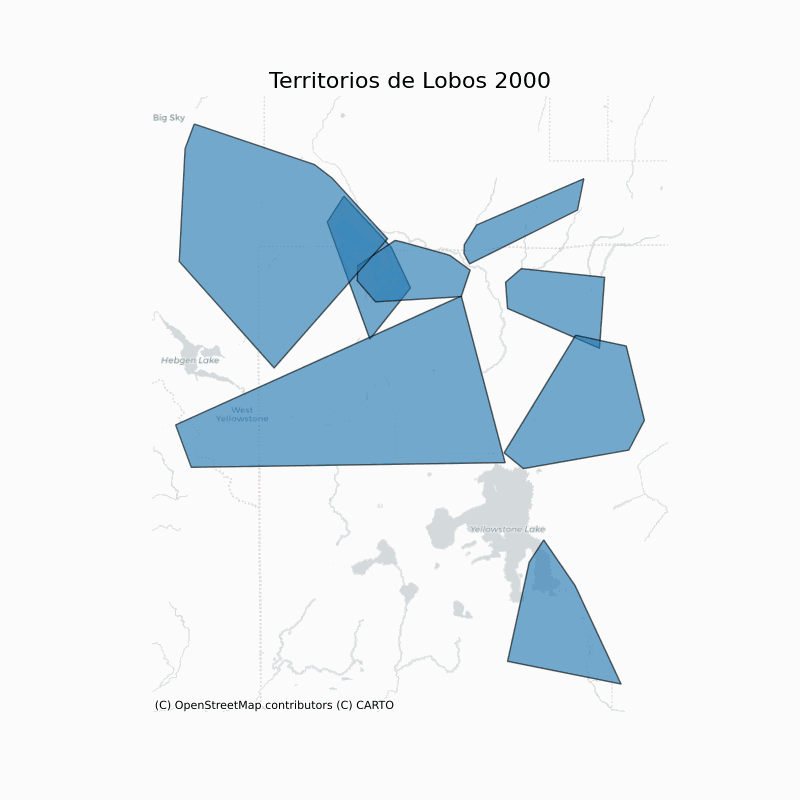

In [400]:
from IPython.display import Image

Image(filename="territorio_tiempo.gif")

# Analizamos el aumento de área en el tiempo.

In [391]:
areas = []

for key in all_wolf_yearly.keys():
    area = all_wolf_yearly[key].unary_union.area
    area_km2 = area * 10e-6
    areas.append(area_km2)


C:\Users\class\AppData\Local\Temp\ipykernel_22408\2295496749.py:4: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  area = all_wolf_yearly[key].unary_union.area


In [392]:
years = [2000, 2001, 2002, 2003, 
         2005, 2006, 2011, 2012, 
         2013, 2014, 2015, 2016, 
         2017, 2018, 2019, 2021, 
         2022, 2008, 2009, 2010]

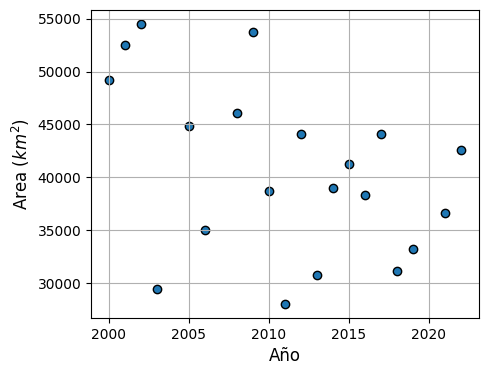

In [401]:
plt.figure(figsize=[5,4])
plt.scatter(years, areas, edgecolors='black')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Area ($km^2$)', fontsize=12)
plt.grid()